# RQ10 — Binding First

## Research question

> Can the mechanically binding wheel be identified first and used to define the wheel-solving order?

RQ9 showed that one universal wheel-invariant true-gate event is too weak to serve as the primary detector. A different physical interpretation was therefore explored historically: rather than ranking digits immediately, first determine **which wheel is currently binding**, solve that wheel, update the lock state, and repeat.

This is the deprecated **Binding-first** route.

### Important chronology rule

RQ10 only evaluates the old Binding-first formulation. The later scan-level Binding state detector / safety-veto work belongs to **RQ20** and is deliberately excluded from the RQ10 decision.

### What is recoverable

The historical project record preserves:

- the manually observed mechanical sequence used to define Binding labels;
- the old S1/S2/S3 formulation;
- the fact that 2D-CNN, LSTM, GRU and Transformer variants were attempted;
- several early raw full-revolution Binding sweep folders in Google Drive.

The exact historical deep-model checkpoints and exact metric tables were **not recovered**. They are therefore not recreated from memory or replaced with invented numbers.

RQ10 is consequently a **formulation-validity reconstruction**: was there a unique, stable target wheel for a Binding-first hierarchy to learn?

## 1. Observed mechanical ground truth

In [2]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount('/content/drive')

MYDRIVE = Path('/content/drive/MyDrive')
PROJECT_ROOT = MYDRIVE / 'Padlock_Reproduction_v1'

results_candidates = [
    PROJECT_ROOT / 'results',
    PROJECT_ROOT / 'Padlock_Reproduction_v1' / 'results',
]

RESULTS_ROOT = next((p for p in results_candidates if p.exists()), None)

if RESULTS_ROOT is None:
    raise FileNotFoundError('Could not locate Padlock_Reproduction_v1/results.')

RESULT_DIR = RESULTS_ROOT / '10_RQ10_Binding_First'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

sequence = pd.DataFrame([
    {
        'stage': 'S1',
        'control_state': '0000',
        'observed_mechanics': (
            'W1 could not freely rotate into 1; the other wheels could move freely.'
        ),
        'binding_label': 'W1',
        'label_status': 'unique',
    },
    {
        'stage': 'S2',
        'control_state': 'W1 = 1',
        'observed_mechanics': (
            'After setting W1=1, W2 could not freely rotate into 1.'
        ),
        'binding_label': 'W2',
        'label_status': 'unique',
    },
    {
        'stage': 'S3',
        'control_state': 'W1 = 1, W2 = 1',
        'observed_mechanics': (
            'W3 and W4 were both difficult to rotate; their order could not be resolved reliably.'
        ),
        'binding_label': '{W3, W4}',
        'label_status': 'shared_or_ambiguous_late_stage',
    },
])

sequence.to_csv(
    RESULT_DIR / 'RQ10_observed_binding_sequence.csv',
    index=False,
)

display(sequence)

Mounted at /content/drive


,stage,control_state,observed_mechanics,binding_label,label_status
0,S1,0000,W1 could not freely rotate into 1; the other w...,W1,unique
1,S2,W1 = 1,"After setting W1=1, W2 could not freely rotate...",W2,unique
2,S3,"W1 = 1, W2 = 1",W3 and W4 were both difficult to rotate; their...,"{W3, W4}",shared_or_ambiguous_late_stage


The labels were not meant to be imposed from a theoretical wheel order. The project explicitly moved to **manual mechanical confirmation**: the observed binding wheel would define the label, while password digits, unlock stage and the manually observed order would not be supplied to the model as inputs.

That improves label provenance, but it exposes the central problem: the observation itself becomes non-unique at the late stage. The defensible mechanical order is therefore:

**W1 → W2 → {W3, W4}**

rather than a fully linear W1 → W2 → W3 → W4 or W1 → W2 → W4 → W3 sequence.

## 2. Recovered early Binding archive

In [3]:
inventory = pd.DataFrame([
    {'family': 'binding_pilot_r1_unloaded', 'role': 'early repeated sweep pilot', 'recovered_runs': 4, 'tension_state': 'UNLOADED'},
    {'family': 'binding_pilot_r2_unloaded', 'role': 'early repeated sweep pilot', 'recovered_runs': 4, 'tension_state': 'UNLOADED'},
    {'family': 'binding_pilot_r3_unloaded', 'role': 'early repeated sweep pilot', 'recovered_runs': 4, 'tension_state': 'UNLOADED'},
    {'family': 'binding_reference_w1_r1_unloaded', 'role': 'wheel reference sweep', 'recovered_runs': 1, 'tension_state': 'UNLOADED'},
    {'family': 'binding_reference_w2_r1_unloaded', 'role': 'wheel reference sweep', 'recovered_runs': 1, 'tension_state': 'UNLOADED'},
    {'family': 'binding_reference_w3_r1_unloaded', 'role': 'wheel reference sweep', 'recovered_runs': 1, 'tension_state': 'UNLOADED'},
    {'family': 'binding_reference_w4_r1_unloaded', 'role': 'wheel reference sweep', 'recovered_runs': 1, 'tension_state': 'UNLOADED'},
    {'family': 'binding_real_ep01_state2468_unloaded', 'role': 'state probe', 'recovered_runs': 4, 'tension_state': 'UNLOADED'},
    {'family': 'binding_real_ep01_state2461_unloaded', 'role': 'state probe', 'recovered_runs': 3, 'tension_state': 'UNLOADED'},
])

inventory.to_csv(
    RESULT_DIR / 'RQ10_recovered_legacy_inventory.csv',
    index=False,
)

display(inventory)

print('Recovered early full-revolution sweeps:', int(inventory['recovered_runs'].sum()))

,family,role,recovered_runs,tension_state
0,binding_pilot_r1_unloaded,early repeated sweep pilot,4,UNLOADED
1,binding_pilot_r2_unloaded,early repeated sweep pilot,4,UNLOADED
2,binding_pilot_r3_unloaded,early repeated sweep pilot,4,UNLOADED
3,binding_reference_w1_r1_unloaded,wheel reference sweep,1,UNLOADED
4,binding_reference_w2_r1_unloaded,wheel reference sweep,1,UNLOADED
5,binding_reference_w3_r1_unloaded,wheel reference sweep,1,UNLOADED
6,binding_reference_w4_r1_unloaded,wheel reference sweep,1,UNLOADED
7,binding_real_ep01_state2468_unloaded,state probe,4,UNLOADED
8,binding_real_ep01_state2461_unloaded,state probe,3,UNLOADED


Recovered early full-revolution sweeps: 23


The recovered early archive contains **23 full-revolution sweeps** across repeated pilots, wheel references and two real-state probes. These recovered folders are explicitly marked `UNLOADED` in their folder names, and representative metadata also records `tension_state = UNLOADED` and `collection_mode = binding_sweep`.

This describes the **recovered early archive only**. It must not be generalized into a claim that every later Binding experiment was unloaded.

## 3. Historical model-capacity attempts

In [4]:
model_attempts = pd.DataFrame([
    {
        'model_family': '2D-CNN',
        'historical_status': 'attempted',
        'exact_metric_recovered': False,
        'scientific_role': 'capacity check on legacy Binding formulation',
    },
    {
        'model_family': 'LSTM',
        'historical_status': 'attempted',
        'exact_metric_recovered': False,
        'scientific_role': 'sequence-model capacity check',
    },
    {
        'model_family': 'GRU',
        'historical_status': 'attempted',
        'exact_metric_recovered': False,
        'scientific_role': 'sequence-model capacity check',
    },
    {
        'model_family': 'Transformer',
        'historical_status': 'attempted',
        'exact_metric_recovered': False,
        'scientific_role': 'high-capacity sequence-model check',
    },
])

model_attempts.to_csv(
    RESULT_DIR / 'RQ10_legacy_model_attempts.csv',
    index=False,
)

display(model_attempts)

,model_family,historical_status,exact_metric_recovered,scientific_role
0,2D-CNN,attempted,False,capacity check on legacy Binding formulation
1,LSTM,attempted,False,sequence-model capacity check
2,GRU,attempted,False,sequence-model capacity check
3,Transformer,attempted,False,high-capacity sequence-model check


No exact accuracy, F1 or loss value is reported here because the corresponding historical model artifacts and metric tables were not recovered.

That omission is scientifically important. The RQ10 decision does **not** depend on claiming that a particular architecture scored poorly. The more fundamental failure occurs one level earlier: by S3 the mechanical target is no longer a unique wheel. A larger sequence model cannot make an ambiguous label physically unique.

## 4. Report figures

In [5]:
import matplotlib.pyplot as plt

DARK_BLUE = '#315B7D'
MID_BLUE = '#6F8FA8'
LIGHT_BLUE = '#AFC5D5'
MID_GREY = '#9EA5AA'
DARK_GREY = '#596168'

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f'{stem}.png',
        dpi=300,
        bbox_inches='tight',
    )
    fig.savefig(
        RESULT_DIR / f'{stem}.pdf',
        bbox_inches='tight',
    )

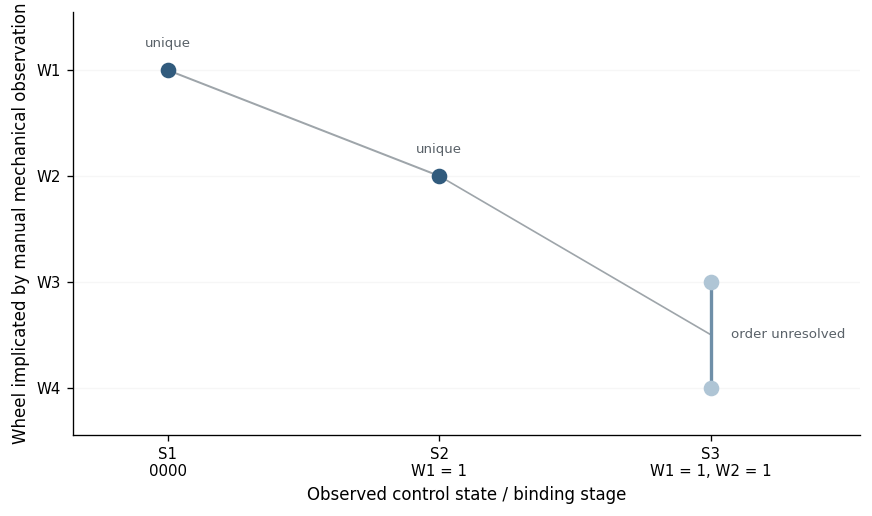

In [6]:
# Main Figure 1 — where the mechanically observed hierarchy loses a unique target.

fig, ax = plt.subplots(
    figsize=(7.4, 4.4)
)

ax.plot(
    [1, 2],
    [4, 3],
    color=MID_GREY,
    linewidth=1.2,
    zorder=1,
)

ax.scatter(
    [1, 2],
    [4, 3],
    s=70,
    color=DARK_BLUE,
    zorder=3,
)

ax.text(
    1,
    4.22,
    'unique',
    ha='center',
    fontsize=8,
    color=DARK_GREY,
)

ax.text(
    2,
    3.22,
    'unique',
    ha='center',
    fontsize=8,
    color=DARK_GREY,
)

ax.plot(
    [2, 3],
    [3, 1.5],
    color=MID_GREY,
    linewidth=1.0,
    zorder=1,
)

ax.vlines(
    3,
    1,
    2,
    color=MID_BLUE,
    linewidth=2.0,
    zorder=2,
)

ax.scatter(
    [3, 3],
    [2, 1],
    s=70,
    color=LIGHT_BLUE,
    zorder=3,
)

ax.annotate(
    'order unresolved',
    xy=(3, 1.5),
    xytext=(12, 0),
    textcoords='offset points',
    va='center',
    fontsize=8,
    color=DARK_GREY,
)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([
    'S1\n0000',
    'S2\nW1 = 1',
    'S3\nW1 = 1, W2 = 1',
])

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['W4', 'W3', 'W2', 'W1'])

ax.set_xlabel(
    'Observed control state / binding stage'
)

ax.set_ylabel(
    'Wheel implicated by manual mechanical observation'
)

ax.set_xlim(0.65, 3.55)
ax.set_ylim(0.55, 4.55)
ax.grid(axis='y', alpha=0.10)

fig.tight_layout()

save_figure(
    fig,
    'RQ10_Fig1_observed_binding_sequence',
)

plt.show()

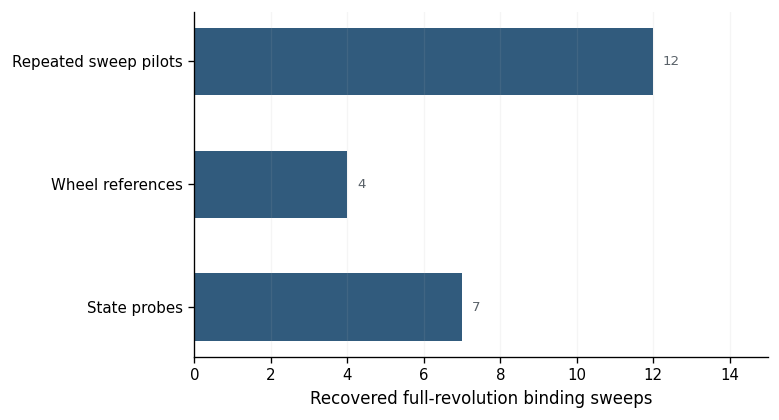

In [7]:
# Supporting Figure 2 — recovered early raw archive size.

inventory_summary = (
    inventory.assign(
        family_group=inventory['role'].map({
            'early repeated sweep pilot': 'Repeated sweep pilots',
            'wheel reference sweep': 'Wheel references',
            'state probe': 'State probes',
        })
    )
    .groupby('family_group', as_index=False)['recovered_runs']
    .sum()
)

order = [
    'Repeated sweep pilots',
    'Wheel references',
    'State probes',
]

inventory_summary['family_group'] = pd.Categorical(
    inventory_summary['family_group'],
    categories=order,
    ordered=True,
)

inventory_summary = inventory_summary.sort_values('family_group')

inventory_summary.to_csv(
    RESULT_DIR / 'RQ10_recovered_inventory_summary.csv',
    index=False,
)

fig, ax = plt.subplots(
    figsize=(6.6, 3.6)
)

y = np.arange(
    len(inventory_summary)
)

values = inventory_summary['recovered_runs'].to_numpy()

ax.barh(
    y,
    values,
    color=DARK_BLUE,
    edgecolor='none',
    height=0.55,
)

for yi, value in zip(y, values):
    ax.text(
        value + 0.25,
        yi,
        str(int(value)),
        va='center',
        fontsize=8,
        color=DARK_GREY,
    )

ax.set_yticks(y)
ax.set_yticklabels(
    inventory_summary['family_group']
)
ax.invert_yaxis()
ax.set_xlabel(
    'Recovered full-revolution binding sweeps'
)
ax.set_xlim(
    0,
    max(values) + 3,
)
ax.grid(
    axis='x',
    alpha=0.12,
)

fig.tight_layout()

save_figure(
    fig,
    'RQ10_Fig2_recovered_legacy_inventory',
)

plt.show()

## 5. Formulation decision

A Binding-first hierarchy requires a **single next wheel** to exist at every stage.

The mechanical observations only support that assumption for the first two stages. At the late stage, both W3 and W4 become difficult and the order cannot be resolved reliably. Forcing one of them to be the class label would convert a real mechanical ambiguity into artificial supervised ground truth.

The old deep-model experiments are therefore best interpreted as attempts to rescue a target definition that was itself unstable, not as a clean architecture benchmark.

### Decision

**Binding-first is deprecated as the primary solution.**

The next formulation should not require one globally correct binding-wheel class before digit inference. This motivates the controlled Digit Scan task used from RQ11 onward: compare the ten one-digit candidates under the same current mechanical state and rank them directly.

### Chronology guard

Binding is revisited later in **RQ20** under a different target: scan-level state detection / safety veto. Those later results are not used retroactively here.

## 6. Result record

In [8]:
conclusion = {
    'research_question': (
        'Can Binding first identify which wheel should be solved?'
    ),
    'analysis_type': (
        'Formulation-validity reconstruction of the deprecated Binding-first route'
    ),
    'observed_mechanical_sequence': {
        'S1': '0000 -> W1 binding was uniquely observed.',
        'S2': 'After W1=1 -> W2 binding was uniquely observed.',
        'S3': (
            'After W1=1 and W2=1 -> W3 and W4 were both difficult; '
            'ordering was unresolved.'
        ),
        'partial_order': 'W1 -> W2 -> {W3, W4}',
    },
    'label_policy': (
        'Binding labels were intended to come from manual mechanical observation '
        'rather than from a fixed assumed wheel order. Combination digits, unlock '
        'stage and human order were not intended as model inputs.'
    ),
    'historical_model_attempts': [
        '2D-CNN',
        'LSTM',
        'GRU',
        'Transformer',
    ],
    'exact_historical_model_metrics_recovered': False,
    'recovered_early_raw_archive': {
        'full_revolution_sweeps': int(
            inventory['recovered_runs'].sum()
        ),
        'note': (
            'The recovered early pilot/reference/state-probe folders are explicitly '
            'UNLOADED. This is an archive description, not a claim that every later '
            'Binding experiment was unloaded.'
        ),
    },
    'interpretation': (
        'The Binding-first hypothesis had real mechanical support at the first two '
        'stages, but it did not yield a unique wheel label throughout the hierarchy. '
        'The observed sequence becomes W1 -> W2 -> {W3,W4}; at the late stage both '
        'W3 and W4 are mechanically difficult and their ordering cannot be resolved '
        'reliably. Once the target label is shared or ambiguous, increasing model '
        'capacity cannot make the hierarchical target well-defined. Historical deep-model '
        'attempts therefore do not rescue the formulation, and exact performance values '
        'are not invented here because the corresponding model assets/results were not recovered.'
    ),
    'limitation': (
        'RQ10 is a formulation-validity reconstruction rather than a fresh benchmark '
        'of the old deep architectures. Exact S1/S2/S3 model checkpoints and metric '
        'tables were not recovered. The decision is grounded in the recorded mechanical '
        'sequence, label provenance and archived protocol evidence rather than reconstructed '
        'deep-model accuracy.'
    ),
    'decision': (
        'Deprecate Binding-first as the primary hierarchy. Do not force W3/W4 into '
        'an artificial linear binding order. Reformulate the main task as controlled '
        'Digit Scan relative ranking; revisit Binding later only under a better-defined '
        'state-detection/safety-veto target.'
    ),
    'later_work_exclusion': (
        'RQ20 scan-level state-detector results are chronologically later and are not '
        'used as evidence for the RQ10 decision.'
    ),
    'next_step': (
        'RQ11 reformulates the problem from hierarchical Binding-first classification '
        'to controlled relative ranking of one-digit movements.'
    ),
}

with open(
    RESULT_DIR / 'RQ10_conclusion.json',
    'w',
    encoding='utf-8',
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )

run_info = {
    'notebook': '10_RQ10_Binding_First.ipynb',
    'research_role': 'legacy Binding-first formulation audit',
    'source_types': [
        'recorded manual mechanical observations',
        'recovered Google Drive legacy binding folder inventory',
        'project handoff record of model families attempted',
    ],
    'recovered_legacy_families': inventory['family'].tolist(),
    'recovered_legacy_run_count': int(
        inventory['recovered_runs'].sum()
    ),
    'deep_model_metrics_policy': (
        'Do not invent exact metrics when historical result assets are absent.'
    ),
    'chronology_guard': (
        'Later RQ20 state-detector results are excluded from the RQ10 decision.'
    ),
}

with open(
    RESULT_DIR / 'RQ10_run_info.json',
    'w',
    encoding='utf-8',
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print('\nSaved outputs:')
for path in sorted(
    RESULT_DIR.glob('RQ10_*')
):
    print(' -', path.name)

{
  "research_question": "Can Binding first identify which wheel should be solved?",
  "analysis_type": "Formulation-validity reconstruction of the deprecated Binding-first route",
  "observed_mechanical_sequence": {
    "S1": "0000 -> W1 binding was uniquely observed.",
    "S2": "After W1=1 -> W2 binding was uniquely observed.",
    "S3": "After W1=1 and W2=1 -> W3 and W4 were both difficult; ordering was unresolved.",
    "partial_order": "W1 -> W2 -> {W3, W4}"
  },
  "label_policy": "Binding labels were intended to come from manual mechanical observation rather than from a fixed assumed wheel order. Combination digits, unlock stage and human order were not intended as model inputs.",
  "historical_model_attempts": [
    "2D-CNN",
    "LSTM",
    "GRU",
    "Transformer"
  ],
  "exact_historical_model_metrics_recovered": false,
  "recovered_early_raw_archive": {
    "full_revolution_sweeps": 23,
    "note": "The recovered early pilot/reference/state-probe folders are explicitly UNLO